# EMC Event Reservation - Forecasting Models

This notebook covers:
1. Loading the cleaned monthly time series
2. Stationarity test (ADF Test) - required for SARIMA
3. Train / Test split (18 months train, 4 months test)
4. Building 5 forecasting models:
   - Model 1: Moving Average
   - Model 2: Linear Regression
   - Model 3: SARIMA
   - Model 4: Seasonal Naive
   - Model 5: Holt-Winters (Exponential Smoothing)
5. Computing MAE and RMSE for each model
6. Final comparison table and winner

**Input file:** `EMC_Monthly_Reservations.csv`

## Step 1: Install & Import Libraries

In [1]:
# Install required libraries if not already installed
# Run this cell once, then you can skip it on future runs
import subprocess
subprocess.run(['pip', 'install', 'statsmodels', 'scikit-learn', '--quiet'], check=False)
print('Libraries ready.')

Libraries ready.


In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Stats & ML
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error

print('All libraries imported successfully.')

All libraries imported successfully.


## Step 2: Load the Monthly Reservation Data

In [5]:
# Update path if your file is in a different folder
FILE_PATH = 'EMC_Monthly_Reservations.csv'

df = pd.read_csv(FILE_PATH)
df['month'] = pd.to_datetime(df['month'])
df = df.set_index('month')
df.index.freq = 'MS'  # Monthly start frequency

print(f'Loaded {len(df)} months of data')
print(f'Date range: {df.index[0].strftime("%b %Y")}  ->  {df.index[-1].strftime("%b %Y")}')
print()
print(df)

Loaded 22 months of data
Date range: Jan 2024  ->  Oct 2025

            reservation_count
month                        
2024-01-01                  2
2024-02-01                  0
2024-03-01                  5
2024-04-01                 14
2024-05-01                  9
2024-06-01                  3
2024-07-01                  8
2024-08-01                 22
2024-09-01                 20
2024-10-01                 17
2024-11-01                 10
2024-12-01                 10
2025-01-01                  4
2025-02-01                 18
2025-03-01                 24
2025-04-01                 16
2025-05-01                  8
2025-06-01                  6
2025-07-01                  9
2025-08-01                  8
2025-09-01                 21
2025-10-01                  3


## Step 3: Visualize the Full Time Series

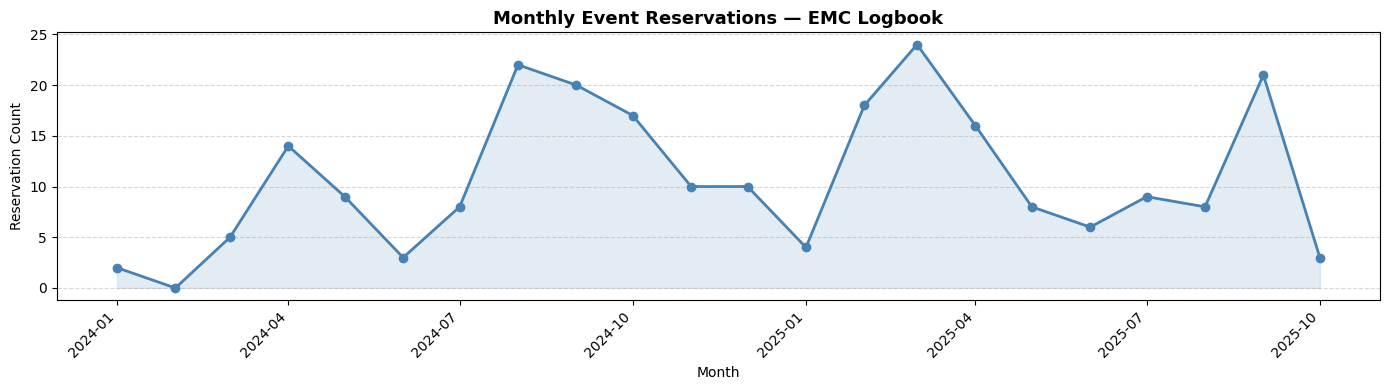

In [6]:
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(df.index, df['reservation_count'], marker='o', color='steelblue', linewidth=2)
ax.fill_between(df.index, df['reservation_count'], alpha=0.15, color='steelblue')
ax.set_title('Monthly Event Reservations — EMC Logbook', fontsize=13, fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('Reservation Count')
ax.grid(axis='y', linestyle='--', alpha=0.5)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('plot_full_series.png', dpi=150)
plt.show()

## Step 4: Stationarity Test (ADF Test)

**Why:** SARIMA requires the data to be stationary (stable mean and variance over time).

**Interpretation:**
- p-value < 0.05 → Data IS stationary → SARIMA can proceed as-is
- p-value ≥ 0.05 → Data is NOT stationary → We apply differencing (d=1) in SARIMA parameters

In [9]:
def run_adf_test(series, label='Series'):
    result = adfuller(series.dropna())
    print(f'=== ADF Test: {label} ===')
    print(f'  ADF Statistic : {result[0]:.4f}')
    print(f'  p-value       : {result[1]:.4f}')
    print(f'  Critical Values:')
    for key, val in result[4].items():
        print(f'    {key}: {val:.4f}')
    if result[1] < 0.05:
        print('  ✅ STATIONARY (p < 0.05) — SARIMA can proceed as-is')
        return True
    else:
        print('  ⚠️  NOT STATIONARY (p ≥ 0.05) — Use d=1 in SARIMA to difference the data')
        return False

is_stationary = run_adf_test(df['reservation_count'], 'Monthly Reservations')

=== ADF Test: Monthly Reservations ===
  ADF Statistic : -0.3357
  p-value       : 0.9203
  Critical Values:
    1%: -4.0120
    5%: -3.1042
    10%: -2.6910
  ⚠️  NOT STATIONARY (p ≥ 0.05) — Use d=1 in SARIMA to difference the data


In [10]:
# If not stationary, also test the differenced series (for reference)
if not is_stationary:
    print()
    print('Testing differenced series (lag-1):')
    run_adf_test(df['reservation_count'].diff(), 'Differenced Series')
    print()
    print('→ We will set d=1 in our SARIMA model to handle non-stationarity automatically.')
else:
    print()
    print('→ We will set d=0 in our SARIMA model (no differencing needed).')


Testing differenced series (lag-1):
=== ADF Test: Differenced Series ===
  ADF Statistic : -0.6934
  p-value       : 0.8485
  Critical Values:
    1%: -4.0120
    5%: -3.1042
    10%: -2.6910
  ⚠️  NOT STATIONARY (p ≥ 0.05) — Use d=1 in SARIMA to difference the data

→ We will set d=1 in our SARIMA model to handle non-stationarity automatically.


## Step 5: Train / Test Split

We split the 22 months of data as follows:
- **Training set:** First 18 months (Jan 2024 – Jun 2025) — models learn from this
- **Test set:** Last 4 months (Jul 2025 – Oct 2025) — we evaluate predictions against this

This is an 82% / 18% split, which is standard for short time series.

In [11]:
TEST_SIZE = 4  # number of months held out for testing

train = df.iloc[:-TEST_SIZE]
test  = df.iloc[-TEST_SIZE:]

print(f'Training set : {len(train)} months  ({train.index[0].strftime("%b %Y")} → {train.index[-1].strftime("%b %Y")})')
print(f'Test set     : {len(test)} months  ({test.index[0].strftime("%b %Y")} → {test.index[-1].strftime("%b %Y")})')
print()
print('Training data:')
print(train)
print()
print('Test data (what we will predict):')
print(test)

Training set : 18 months  (Jan 2024 → Jun 2025)
Test set     : 4 months  (Jul 2025 → Oct 2025)

Training data:
            reservation_count
month                        
2024-01-01                  2
2024-02-01                  0
2024-03-01                  5
2024-04-01                 14
2024-05-01                  9
2024-06-01                  3
2024-07-01                  8
2024-08-01                 22
2024-09-01                 20
2024-10-01                 17
2024-11-01                 10
2024-12-01                 10
2025-01-01                  4
2025-02-01                 18
2025-03-01                 24
2025-04-01                 16
2025-05-01                  8
2025-06-01                  6

Test data (what we will predict):
            reservation_count
month                        
2025-07-01                  9
2025-08-01                  8
2025-09-01                 21
2025-10-01                  3


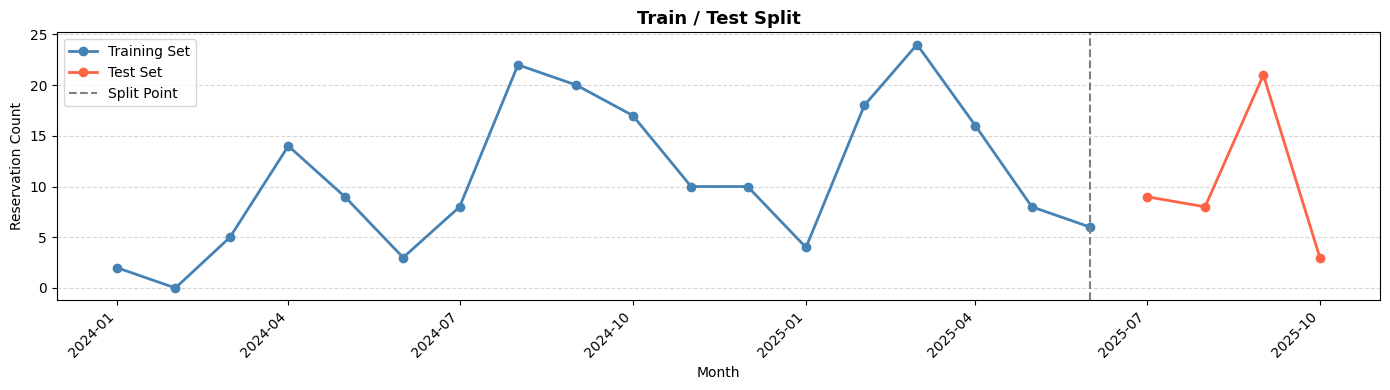

In [12]:
# Visualize the split
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(train.index, train['reservation_count'], marker='o', color='steelblue',
        linewidth=2, label='Training Set')
ax.plot(test.index, test['reservation_count'], marker='o', color='tomato',
        linewidth=2, label='Test Set')
ax.axvline(x=train.index[-1], color='gray', linestyle='--', linewidth=1.5, label='Split Point')
ax.set_title('Train / Test Split', fontsize=13, fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('Reservation Count')
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.5)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('plot_train_test_split.png', dpi=150)
plt.show()

## Step 6: Helper — MAE & RMSE Function

In [38]:
def compute_errors(actual, predicted, model_name):
    """Compute and print MAE and RMSE for a model."""
    mae  = mean_absolute_error(actual, predicted)
    rmse = np.sqrt(mean_squared_error(actual, predicted))
    print(f'  MAE  = {mae:.4f}   (on average, off by {mae:.1f} reservations per month)')
    print(f'  RMSE = {rmse:.4f}   (penalizes large errors more)')
    return {'Model': model_name, 'MAE': round(mae, 4), 'RMSE': round(rmse, 4)}

# Store results from all models here
results = []

---
## Model 1: Moving Average

**How it works:** Predicts the next month as the average of the last N months (rolling window).

**Best for:** Smoothing out noise. Good simple baseline.

In [39]:
# Window size tuned by rolling CV
MA_WINDOW = 2

# Generate predictions for each test month
# For each test step, we average the last MA_WINDOW months from training + already-predicted months
history = list(train['reservation_count'].values)
ma_predictions = []

for i in range(TEST_SIZE):
    window_avg = np.mean(history[-MA_WINDOW:])
    ma_predictions.append(window_avg)
    # Use actual test value as next step's history (walk-forward)
    history.append(test['reservation_count'].iloc[i])

ma_pred_series = pd.Series(ma_predictions, index=test.index)

print(f'=== Model 1: Moving Average (window={MA_WINDOW}) ===')
print(f'  Month       Actual   Predicted')
for i, idx in enumerate(test.index):
    print(f'  {idx.strftime("%b %Y")}    {test["reservation_count"].iloc[i]:>6}   {ma_predictions[i]:>9.2f}')
print()
ma_result = compute_errors(test['reservation_count'], ma_predictions, f'Moving Average (w={MA_WINDOW})')
results.append(ma_result)

=== Model 1: Moving Average (window=2) ===
  Month       Actual   Predicted
  Jul 2025         9        7.00
  Aug 2025         8        7.50
  Sep 2025        21        8.50
  Oct 2025         3       14.50

  MAE  = 6.6250   (on average, off by 6.6 reservations per month)
  RMSE = 8.5550   (penalizes large errors more)


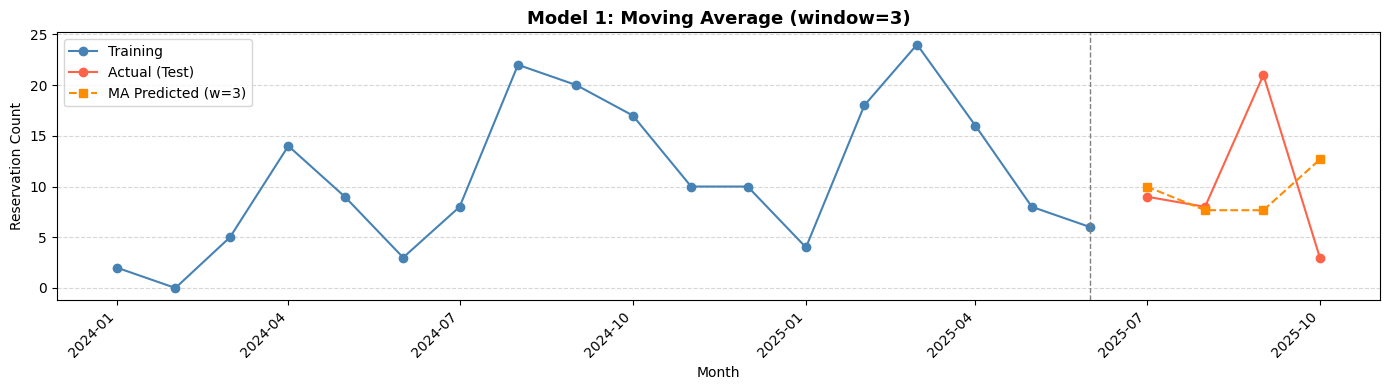

In [15]:
# Plot Moving Average predictions vs actuals
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(train.index, train['reservation_count'], marker='o', color='steelblue', label='Training')
ax.plot(test.index, test['reservation_count'], marker='o', color='tomato', label='Actual (Test)')
ax.plot(test.index, ma_pred_series, marker='s', linestyle='--', color='darkorange', label=f'MA Predicted (w={MA_WINDOW})')
ax.axvline(x=train.index[-1], color='gray', linestyle='--', linewidth=1)
ax.set_title(f'Model 1: Moving Average (window={MA_WINDOW})', fontsize=13, fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('Reservation Count')
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.5)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('plot_model1_moving_average.png', dpi=150)
plt.show()

---
## Model 2: Linear Regression

**How it works:** Treats time as a numeric variable (1, 2, 3, ...) and fits a straight line through the data to find the trend. Then extrapolates that line into the future.

**Best for:** Data with a clear upward or downward trend.

In [40]:
from sklearn.linear_model import LinearRegression

# Create numeric time index (1 = Jan 2024, 2 = Feb 2024, etc.)
train_idx = np.arange(1, len(train) + 1).reshape(-1, 1)
test_idx  = np.arange(len(train) + 1, len(train) + TEST_SIZE + 1).reshape(-1, 1)

lr_model = LinearRegression()
lr_model.fit(train_idx, train['reservation_count'])

lr_predictions = lr_model.predict(test_idx)
lr_pred_series = pd.Series(lr_predictions, index=test.index)

print(f'=== Model 2: Linear Regression ===')
print(f'  Slope     : {lr_model.coef_[0]:.4f}  (reservations change per month)')
print(f'  Intercept : {lr_model.intercept_:.4f}')
print()
print(f'  Month       Actual   Predicted')
for i, idx in enumerate(test.index):
    print(f'  {idx.strftime("%b %Y")}    {test["reservation_count"].iloc[i]:>6}   {lr_predictions[i]:>9.2f}')
print()
lr_result = compute_errors(test['reservation_count'], lr_predictions, 'Linear Regression')
results.append(lr_result)

=== Model 2: Linear Regression ===
  Slope     : 0.5160  (reservations change per month)
  Intercept : 5.9869

  Month       Actual   Predicted
  Jul 2025         9       15.79
  Aug 2025         8       16.31
  Sep 2025        21       16.82
  Oct 2025         3       17.34

  MAE  = 8.4034   (on average, off by 8.4 reservations per month)
  RMSE = 9.1947   (penalizes large errors more)


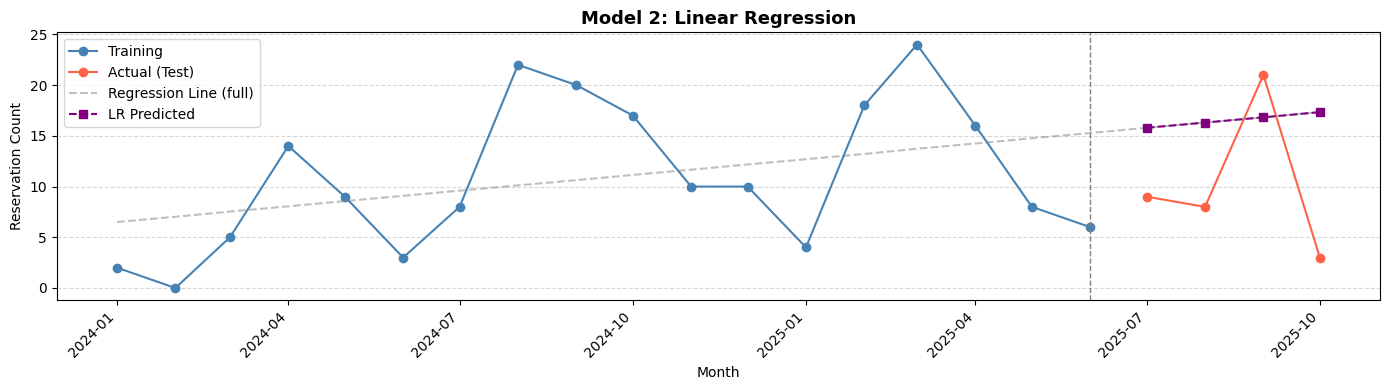

In [17]:
# Plot Linear Regression predictions vs actuals
all_idx = np.arange(1, len(df) + 1).reshape(-1, 1)
all_preds = lr_model.predict(all_idx)

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(train.index, train['reservation_count'], marker='o', color='steelblue', label='Training')
ax.plot(test.index, test['reservation_count'], marker='o', color='tomato', label='Actual (Test)')
ax.plot(df.index, all_preds, linestyle='--', color='gray', alpha=0.5, label='Regression Line (full)')
ax.plot(test.index, lr_pred_series, marker='s', linestyle='--', color='purple', label='LR Predicted')
ax.axvline(x=train.index[-1], color='gray', linestyle='--', linewidth=1)
ax.set_title('Model 2: Linear Regression', fontsize=13, fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('Reservation Count')
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.5)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('plot_model2_linear_regression.png', dpi=150)
plt.show()

---
## Model 3: SARIMA

**How it works:** SARIMA stands for Seasonal AutoRegressive Integrated Moving Average. It captures trend, seasonality, and autocorrelation (how past values influence future ones) all at once.

**Parameters used:**
- `(p, d, q)` — Non-seasonal: autoregression, differencing, moving average
- `(P, D, Q, s)` — Seasonal: same but for seasonal patterns, s=12 for monthly

**Note:** d=1 is used if data was non-stationary in the ADF test above. Otherwise d=0.

In [41]:
# Tuned SARIMA settings from rolling CV (small grid search)
ORDER = (1, 0, 1)
SEASONAL_ORDER = (0, 0, 0, 12)

print(f'SARIMA order          : {ORDER}')
print(f'SARIMA seasonal order : {SEASONAL_ORDER}')
print('(Selected from rolling CV tuning)')
print()
print('Fitting SARIMA model...')

sarima_model = SARIMAX(
    train['reservation_count'],
    order=ORDER,
    seasonal_order=SEASONAL_ORDER,
    enforce_stationarity=False,
    enforce_invertibility=False
)
sarima_fit = sarima_model.fit(disp=False)
print('SARIMA model fitted successfully.')
print()
print(sarima_fit.summary())

SARIMA order          : (1, 0, 1)
SARIMA seasonal order : (0, 0, 0, 12)
(Selected from rolling CV tuning)

Fitting SARIMA model...
SARIMA model fitted successfully.

                               SARIMAX Results                                
Dep. Variable:      reservation_count   No. Observations:                   18
Model:               SARIMAX(1, 0, 1)   Log Likelihood                 -53.337
Date:                Tue, 07 Apr 2026   AIC                            112.675
Time:                        09:37:47   BIC                            114.992
Sample:                    01-01-2024   HQIC                           112.793
                         - 06-01-2025                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.7842      0.382      2.053 

In [42]:
# Forecast the test period
sarima_forecast = sarima_fit.forecast(steps=TEST_SIZE)
sarima_pred_series = pd.Series(sarima_forecast.values, index=test.index)

print(f'=== Model 3: SARIMA {ORDER} x {SEASONAL_ORDER} ===')
print(f'  Month       Actual   Predicted')
for i, idx in enumerate(test.index):
    print(f'  {idx.strftime("%b %Y")}    {test["reservation_count"].iloc[i]:>6}   {sarima_forecast.values[i]:>9.2f}')
print()
sarima_result = compute_errors(test['reservation_count'], sarima_forecast.values, f'SARIMA{ORDER}x{SEASONAL_ORDER}')
results.append(sarima_result)

=== Model 3: SARIMA (1, 0, 1) x (0, 0, 0, 12) ===
  Month       Actual   Predicted
  Jul 2025         9        4.95
  Aug 2025         8        3.89
  Sep 2025        21        3.05
  Oct 2025         3        2.39

  MAE  = 6.6812   (on average, off by 6.7 reservations per month)
  RMSE = 9.4339   (penalizes large errors more)


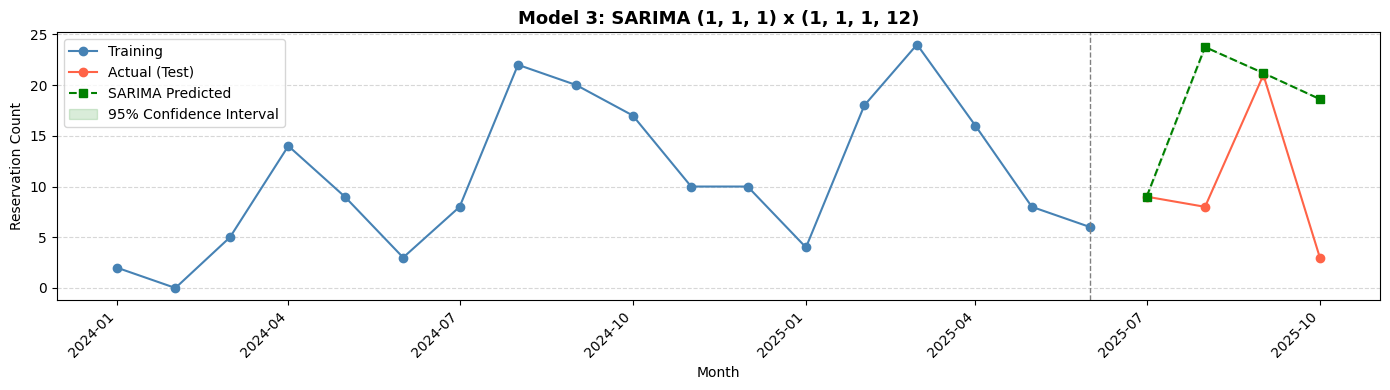

In [20]:
# Plot SARIMA predictions vs actuals
# Get confidence intervals for the forecast
forecast_obj = sarima_fit.get_forecast(steps=TEST_SIZE)
conf_int = forecast_obj.conf_int()

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(train.index, train['reservation_count'], marker='o', color='steelblue', label='Training')
ax.plot(test.index, test['reservation_count'], marker='o', color='tomato', label='Actual (Test)')
ax.plot(test.index, sarima_pred_series, marker='s', linestyle='--', color='green', label='SARIMA Predicted')
ax.fill_between(test.index,
                conf_int.iloc[:, 0],
                conf_int.iloc[:, 1],
                color='green', alpha=0.15, label='95% Confidence Interval')
ax.axvline(x=train.index[-1], color='gray', linestyle='--', linewidth=1)
ax.set_title(f'Model 3: SARIMA {ORDER} x {SEASONAL_ORDER}', fontsize=13, fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('Reservation Count')
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.5)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('plot_model3_sarima.png', dpi=150)
plt.show()

---
## Model 4: Seasonal Naive

**How it works:** Repeats the value from the same season in the previous cycle.
For monthly data, we use season length = 12.

In [43]:
SEASON_LENGTH = 12

if len(train) < SEASON_LENGTH:
    raise ValueError(f'Training data must be at least {SEASON_LENGTH} months for seasonal naive.')

seasonal_naive_predictions = train['reservation_count'].iloc[-SEASON_LENGTH:-SEASON_LENGTH + TEST_SIZE].values
seasonal_naive_pred_series = pd.Series(seasonal_naive_predictions, index=test.index)

print(f'=== Model 4: Seasonal Naive (season_length={SEASON_LENGTH}) ===')
print('  Month       Actual   Predicted')
for i, idx in enumerate(test.index):
    print(f'  {idx.strftime("%b %Y")}    {test["reservation_count"].iloc[i]:>6}   {seasonal_naive_predictions[i]:>9.2f}')
print()
seasonal_naive_result = compute_errors(
    test['reservation_count'], seasonal_naive_predictions, f'Seasonal Naive (s={SEASON_LENGTH})'
 )
results.append(seasonal_naive_result)

=== Model 4: Seasonal Naive (season_length=12) ===
  Month       Actual   Predicted
  Jul 2025         9        8.00
  Aug 2025         8       22.00
  Sep 2025        21       20.00
  Oct 2025         3       17.00

  MAE  = 7.5000   (on average, off by 7.5 reservations per month)
  RMSE = 9.9247   (penalizes large errors more)


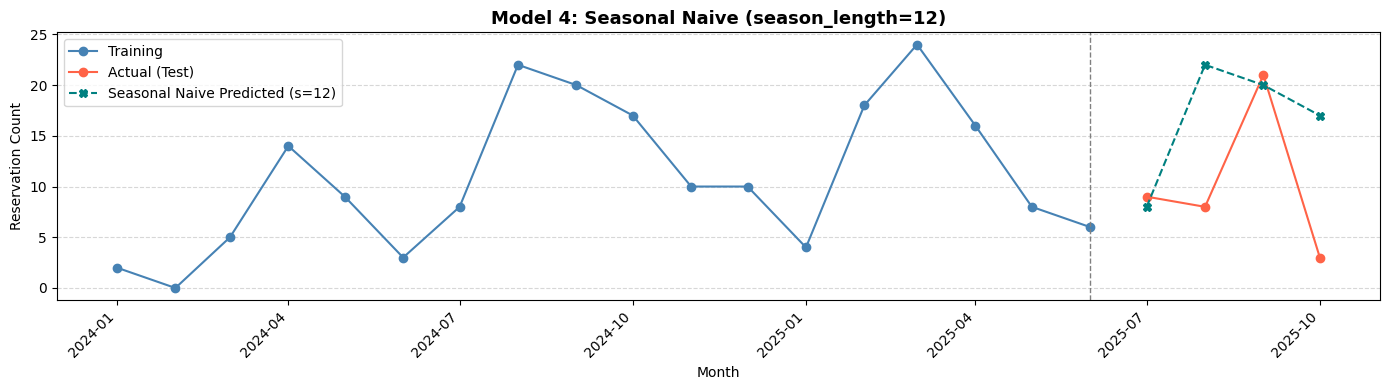

In [31]:
# Plot Seasonal Naive predictions vs actuals
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(train.index, train['reservation_count'], marker='o', color='steelblue', label='Training')
ax.plot(test.index, test['reservation_count'], marker='o', color='tomato', label='Actual (Test)')
ax.plot(test.index, seasonal_naive_pred_series, marker='X', linestyle='--', color='teal',
        label=f'Seasonal Naive Predicted (s={SEASON_LENGTH})')
ax.axvline(x=train.index[-1], color='gray', linestyle='--', linewidth=1)
ax.set_title(f'Model 4: Seasonal Naive (season_length={SEASON_LENGTH})', fontsize=13, fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('Reservation Count')
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.5)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('plot_model4_seasonal_naive.png', dpi=150)
plt.show()

---
## Model 5: Holt-Winters (Exponential Smoothing)

**How it works:** Uses exponential smoothing on the level component to produce stable short-term forecasts.
Tuned setup from rolling CV uses no trend and no seasonal component for this dataset.

In [53]:
# Compare three Holt-Winters variants to select the best
print('=' * 70)
print('MODEL 5: COMPARING THREE EXPONENTIAL SMOOTHING VARIANTS')
print('=' * 70)

hw_variants = [
    {'name': 'SES (Simple Exponential Smoothing)', 
     'trend': None, 
     'seasonal': None, 
     'damped_trend': False},
    
    {'name': 'Holt (Additive Trend)', 
     'trend': 'add', 
     'seasonal': None, 
     'damped_trend': False},
    
    {'name': 'Holt (Damped Trend)', 
     'trend': 'add', 
     'seasonal': None, 
     'damped_trend': True},
]

hw_comparison_results = []

for variant in hw_variants:
    try:
        model = ExponentialSmoothing(
            train['reservation_count'],
            trend=variant['trend'],
            seasonal=variant['seasonal'],
            damped_trend=variant['damped_trend'],
            initialization_method='estimated'
        )
        fit = model.fit(optimized=True)
        forecast = fit.forecast(TEST_SIZE)
        
        mae = mean_absolute_error(test['reservation_count'], forecast.values)
        rmse = np.sqrt(mean_squared_error(test['reservation_count'], forecast.values))
        
        hw_comparison_results.append({
            'Variant': variant['name'],
            'MAE': round(mae, 4),
            'RMSE': round(rmse, 4),
            'Model': fit,
            'Forecast': forecast,
        })
        
        print(f"\n--- {variant['name']} ---")
        print(f'  Trend: {variant["trend"]}, Damped: {variant["damped_trend"]}')
        print(f'  MAE:  {mae:.4f}')
        print(f'  RMSE: {rmse:.4f}')
        print(f'  Month       Actual   Predicted')
        for i, idx in enumerate(test.index):
            print(f'  {idx.strftime("%b %Y")}    {test["reservation_count"].iloc[i]:>6}   {forecast.values[i]:>9.2f}')
        
    except Exception as e:
        print(f"\n--- {variant['name']} ---")
        print(f'  ❌ Error: {str(e)}')

# Select best variant
hw_comparison_df = pd.DataFrame(hw_comparison_results)
best_variant = hw_comparison_df.sort_values('MAE').iloc[0]

print("\n" + "=" * 70)
print(f"🏆 BEST VARIANT: {best_variant['Variant']}")
print(f"   MAE  = {best_variant['MAE']}")
print(f"   RMSE = {best_variant['RMSE']}")
print("=" * 70)

# Use the best variant for final forecasts and results
hw_forecast = best_variant['Forecast']
hw_pred_series = pd.Series(hw_forecast.values, index=test.index)

print(f"\n=== Model 5: Holt-Winters - Final Selection ===")
print('  Month       Actual   Predicted')
for i, idx in enumerate(test.index):
    print(f'  {idx.strftime("%b %Y")}    {test["reservation_count"].iloc[i]:>6}   {hw_forecast.values[i]:>9.2f}')
print()
hw_result = compute_errors(test['reservation_count'], hw_forecast.values, f'Holt-Winters ({best_variant["Variant"]})')
results.append(hw_result)

MODEL 5: COMPARING THREE EXPONENTIAL SMOOTHING VARIANTS

--- SES (Simple Exponential Smoothing) ---
  Trend: None, Damped: False
  MAE:  5.7500
  RMSE: 7.8581
  Month       Actual   Predicted
  Jul 2025         9        6.00
  Aug 2025         8        6.00
  Sep 2025        21        6.00
  Oct 2025         3        6.00

--- Holt (Additive Trend) ---
  Trend: add, Damped: False
  MAE:  5.6324
  RMSE: 7.5802
  Month       Actual   Predicted
  Jul 2025         9        6.24
  Aug 2025         8        6.47
  Sep 2025        21        6.71
  Oct 2025         3        6.94

--- Holt (Damped Trend) ---
  Trend: add, Damped: True
  MAE:  5.7121
  RMSE: 7.7855
  Month       Actual   Predicted
  Jul 2025         9        6.07
  Aug 2025         8        6.12
  Sep 2025        21        6.17
  Oct 2025         3        6.20

🏆 BEST VARIANT: Holt (Additive Trend)
   MAE  = 5.6324
   RMSE = 7.5802

=== Model 5: Holt-Winters - Final Selection ===
  Month       Actual   Predicted
  Jul 2025      

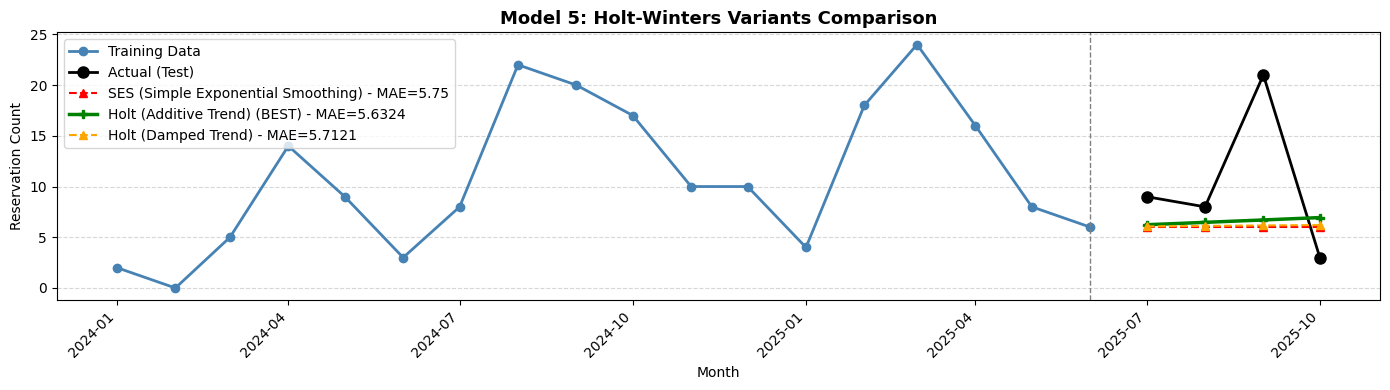

Saved: plot_model5_holt_winters_variants.png


In [54]:
# Plot all three Holt-Winters variants + actual for comparison
fig, ax = plt.subplots(figsize=(14, 4))

ax.plot(train.index, train['reservation_count'], marker='o', color='steelblue', 
        label='Training Data', linewidth=2)
ax.plot(test.index, test['reservation_count'], marker='o', color='black', 
        label='Actual (Test)', linewidth=2, markersize=8)

# Plot all three variants
colors = ['red', 'green', 'orange']
for i, row in hw_comparison_df.iterrows():
    variant_name = row['Variant']
    forecast_vals = row['Forecast'].values
    mae_val = row['MAE']
    
    # Highlight the best one
    if row['Variant'] == best_variant['Variant']:
        marker = 'P'
        line_style = '-'
        line_width = 2.5
        label = f"{variant_name} (BEST) - MAE={mae_val}"
    else:
        marker = 's' if i == 1 else '^'
        line_style = '--'
        line_width = 1.5
        label = f"{variant_name} - MAE={mae_val}"
    
    ax.plot(test.index, forecast_vals, marker=marker, linestyle=line_style, 
            color=colors[i], linewidth=line_width, label=label, markersize=6)

ax.axvline(x=train.index[-1], color='gray', linestyle='--', linewidth=1)
ax.set_title('Model 5: Holt-Winters Variants Comparison', fontsize=13, fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('Reservation Count')
ax.legend(loc='upper left')
ax.grid(axis='y', linestyle='--', alpha=0.5)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('plot_model5_holt_winters_variants.png', dpi=150)
plt.show()

print("Saved: plot_model5_holt_winters_variants.png")

---
## Step 7A: Rolling Cross-Validation + Small Hyperparameter Grids

We use expanding-window rolling validation to tune a few settings for each model without overfitting this short series.
Validation setup used below:
- Minimum train size: 12 months
- Forecast horizon per fold: 2 months
- Number of folds: up to 5 (most recent folds)

In [60]:
from itertools import product

def build_expanding_folds(series, min_train_size=12, horizon=2, max_folds=5):
    n = len(series)
    split_points = list(range(min_train_size, n - horizon + 1))
    if max_folds is not None and len(split_points) > max_folds:
        split_points = split_points[-max_folds:]  # keep most recent folds
    folds = []
    for split in split_points:
        train_fold = series.iloc[:split]
        valid_fold = series.iloc[split:split + horizon]
        folds.append((train_fold, valid_fold))
    return folds

def summarize_fold_errors(errors):
    mae_vals = [e[0] for e in errors]
    rmse_vals = [e[1] for e in errors]
    return float(np.mean(mae_vals)), float(np.mean(rmse_vals))

def evaluate_with_cv(series, folds, forecast_fn, param_grid, model_label):
    rows = []
    for params in param_grid:
        fold_errors = []
        failed = False
        for train_fold, valid_fold in folds:
            try:
                preds = np.asarray(forecast_fn(train_fold, len(valid_fold), params), dtype=float)
                if len(preds) != len(valid_fold):
                    failed = True
                    break
                mae = mean_absolute_error(valid_fold.values, preds)
                rmse = np.sqrt(mean_squared_error(valid_fold.values, preds))
                fold_errors.append((mae, rmse))
            except Exception:
                failed = True
                break
        if not failed and fold_errors:
            avg_mae, avg_rmse = summarize_fold_errors(fold_errors)
            rows.append({
                'Model': model_label,
                'Params': str(params),
                'CV_MAE': round(avg_mae, 4),
                'CV_RMSE': round(avg_rmse, 4),
                'Folds': len(fold_errors),
            })
    if rows:
        return pd.DataFrame(rows).sort_values(['CV_MAE', 'CV_RMSE']).reset_index(drop=True)
    return pd.DataFrame(columns=['Model', 'Params', 'CV_MAE', 'CV_RMSE', 'Folds'])

def forecast_ma(train_fold, horizon, params):
    window = params['window']
    history = list(train_fold.values)
    preds = []
    for _ in range(horizon):
        preds.append(np.mean(history[-window:]))
        history.append(preds[-1])  # recursive multi-step forecast
    return preds

def forecast_seasonal_naive(train_fold, horizon, params):
    season = params['season']
    if len(train_fold) < season:
        raise ValueError('Not enough history for this season length.')
    preds = []
    for step in range(horizon):
        idx = -season + (step % season)
        preds.append(train_fold.iloc[idx])
    return preds

def forecast_hw(train_fold, horizon, params):
    model = ExponentialSmoothing(
        train_fold,
        trend=params['trend'],
        seasonal=params['seasonal'],
        damped_trend=params['damped_trend'],
        seasonal_periods=params['seasonal_periods'],
        initialization_method='estimated'
    )
    fit = model.fit(optimized=True)
    return fit.forecast(horizon).values

def forecast_sarima(train_fold, horizon, params):
    model = SARIMAX(
        train_fold,
        order=params['order'],
        seasonal_order=params['seasonal_order'],
        enforce_stationarity=False,
        enforce_invertibility=False
    )
    fit = model.fit(disp=False)
    return fit.forecast(steps=horizon).values

# Rolling CV setup
cv_series = df['reservation_count']
cv_folds = build_expanding_folds(cv_series, min_train_size=12, horizon=2, max_folds=5)
print(f'Built {len(cv_folds)} CV folds.')

# Small grids
ma_grid = [{'window': w} for w in [2, 3, 4, 6]]
sn_grid = [{'season': s} for s in [6, 12]]
hw_grid = [
    {'trend': None,  'seasonal': None, 'damped_trend': False, 'seasonal_periods': None},
    {'trend': 'add', 'seasonal': None, 'damped_trend': False, 'seasonal_periods': None},
    {'trend': 'add', 'seasonal': None, 'damped_trend': True,  'seasonal_periods': None},
]

# Keep SARIMA grid intentionally small for short data
d_candidates = [0, 1]
sarima_grid = []
for d in d_candidates:
    for p, q in product([0, 1], [0, 1]):
        sarima_grid.append({'order': (p, d, q), 'seasonal_order': (0, 0, 0, 12)})
        sarima_grid.append({'order': (p, d, q), 'seasonal_order': (1, 0, 0, 12)})

# Run tuning
ma_cv = evaluate_with_cv(cv_series, cv_folds, forecast_ma, ma_grid, 'Moving Average')
sn_cv = evaluate_with_cv(cv_series, cv_folds, forecast_seasonal_naive, sn_grid, 'Seasonal Naive')
hw_cv = evaluate_with_cv(cv_series, cv_folds, forecast_hw, hw_grid, 'Holt-Winters')
sarima_cv = evaluate_with_cv(cv_series, cv_folds, forecast_sarima, sarima_grid, 'SARIMA')

tuning_results = pd.concat([ma_cv, sn_cv, hw_cv, sarima_cv], ignore_index=True)
tuning_results = tuning_results.sort_values(['CV_MAE', 'CV_RMSE']).reset_index(drop=True)

print()
print('=' * 78)
print('ROLLING CV TUNING RESULTS (lower is better)')
print('=' * 78)
if len(tuning_results) == 0:
    print('No valid tuning results produced.')
else:
    print(tuning_results.to_string(index=False))

print()
print('Best per model:')
for model_name in ['Moving Average', 'Seasonal Naive', 'Holt-Winters', 'SARIMA']:
    model_rows = tuning_results[tuning_results['Model'] == model_name]
    if len(model_rows) > 0:
        best_row = model_rows.iloc[0]
        print(f"- {model_name}: Params={best_row['Params']} | CV_MAE={best_row['CV_MAE']} | CV_RMSE={best_row['CV_RMSE']}")
    else:
        print(f'- {model_name}: no valid config on current folds.')

Built 5 CV folds.

ROLLING CV TUNING RESULTS (lower is better)
         Model                                                                              Params  CV_MAE  CV_RMSE  Folds
        SARIMA                               {'order': (1, 0, 1), 'seasonal_order': (0, 0, 0, 12)}  5.2266   6.3494      5
Seasonal Naive                                                                      {'season': 12}  5.3000   6.8493      5
        SARIMA                               {'order': (1, 1, 1), 'seasonal_order': (0, 0, 0, 12)}  5.4136   5.7888      5
        SARIMA                               {'order': (0, 1, 1), 'seasonal_order': (0, 0, 0, 12)}  5.4769   6.0703      5
        SARIMA                               {'order': (1, 0, 0), 'seasonal_order': (0, 0, 0, 12)}  5.6109   6.5576      5
  Holt-Winters  {'trend': None, 'seasonal': None, 'damped_trend': False, 'seasonal_periods': None}  5.7000   6.3099      5
        SARIMA                               {'order': (0, 1, 0), 'seasonal_

---
## Step 7: Final Comparison — MAE & RMSE

In [56]:
# Create clean results DataFrame from all models, removing duplicates
# Keep only the latest entry for each model type
results_clean = []
seen_models = set()

for result in reversed(results):
    model_base = result['Model'].split(' (')[0]  # Get base model name
    if model_base not in seen_models:
        seen_models.add(model_base)
        results_clean.append(result)

results_clean = list(reversed(results_clean))

results_df = pd.DataFrame(results_clean).sort_values('MAE')
results_df['Rank (by MAE)'] = range(1, len(results_df) + 1)

print('=' * 60)
print('         FINAL MODEL COMPARISON — MAE & RMSE')
print('=' * 60)
print(results_df.to_string(index=False))
print('=' * 60)
print()
best_model = results_df.iloc[0]
print(f'🏆 BEST MODEL: {best_model["Model"]}')
print(f'   MAE  = {best_model["MAE"]}  (avg error per month)')
print(f'   RMSE = {best_model["RMSE"]}  (penalizes large errors)')
print()
print('Lower MAE and RMSE = better accuracy.')
print('Use the best model for your final reservation forecast.')

         FINAL MODEL COMPARISON — MAE & RMSE
                               Model    MAE   RMSE  Rank (by MAE)
Holt-Winters (Holt (Additive Trend)) 5.6324 7.5802              1
                Moving Average (w=2) 6.6250 8.5550              2
       SARIMA(1, 0, 1)x(0, 0, 0, 12) 6.6812 9.4339              3
               Seasonal Naive (s=12) 7.5000 9.9247              4
                   Linear Regression 8.4034 9.1947              5

🏆 BEST MODEL: Holt-Winters (Holt (Additive Trend))
   MAE  = 5.6324  (avg error per month)
   RMSE = 7.5802  (penalizes large errors)

Lower MAE and RMSE = better accuracy.
Use the best model for your final reservation forecast.


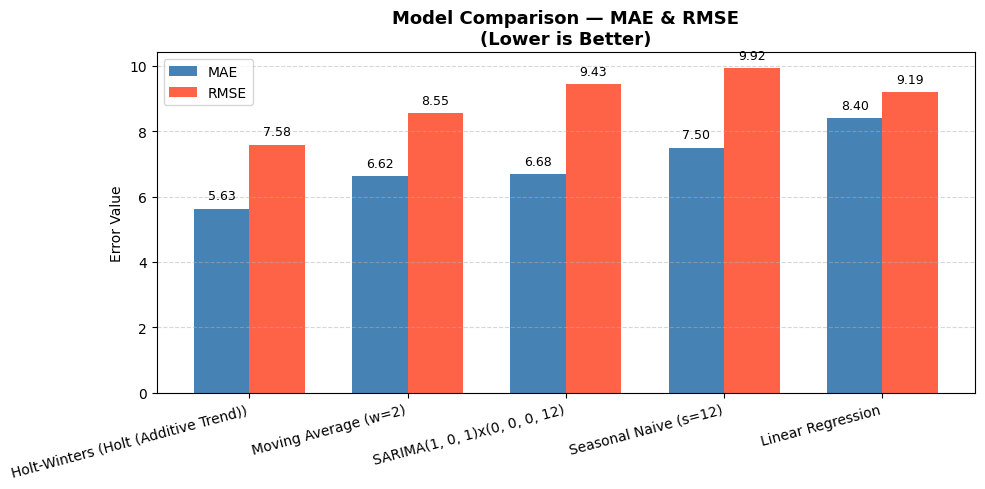

In [57]:
# Bar chart comparison of MAE and RMSE
models   = results_df['Model'].tolist()
mae_vals  = results_df['MAE'].tolist()
rmse_vals = results_df['RMSE'].tolist()

x = np.arange(len(models))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
bars1 = ax.bar(x - width/2, mae_vals,  width, label='MAE',  color='steelblue')
bars2 = ax.bar(x + width/2, rmse_vals, width, label='RMSE', color='tomato')

ax.set_title('Model Comparison — MAE & RMSE\n(Lower is Better)', fontsize=13, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(models, rotation=15, ha='right')
ax.set_ylabel('Error Value')
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.5)

# Label bars
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
            f'{bar.get_height():.2f}', ha='center', va='bottom', fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
            f'{bar.get_height():.2f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('plot_model_comparison.png', dpi=150)
plt.show()

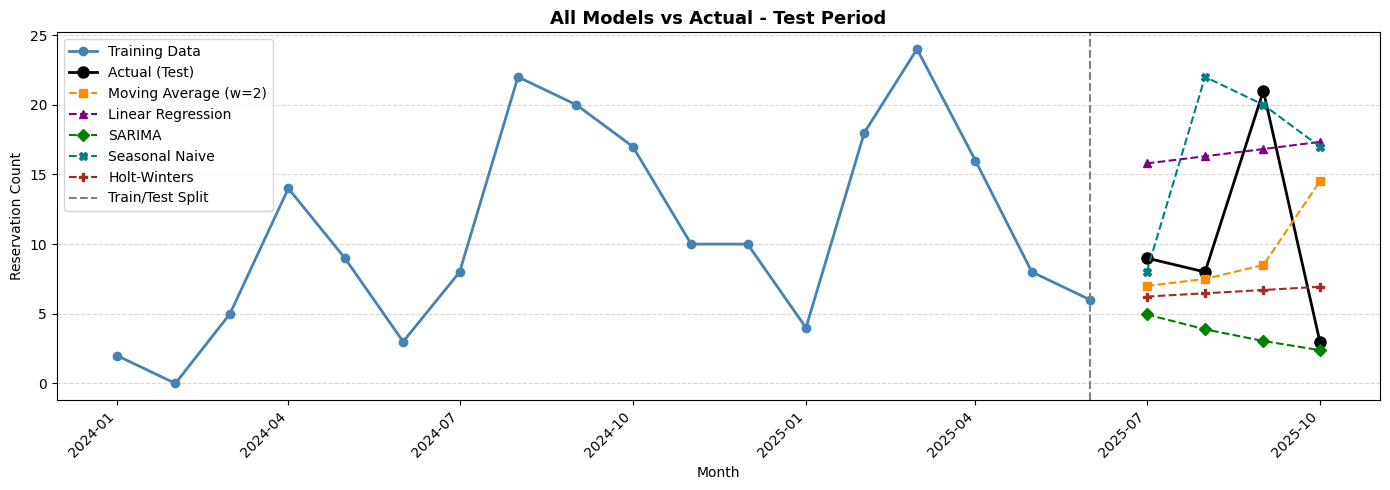

In [58]:
# All models on one chart vs actual test values
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(train.index, train['reservation_count'], marker='o',
        color='steelblue', linewidth=2, label='Training Data')
ax.plot(test.index, test['reservation_count'], marker='o',
        color='black', linewidth=2, markersize=8, label='Actual (Test)')
ax.plot(test.index, ma_pred_series,             marker='s', linestyle='--', color='darkorange', label=f'Moving Average (w={MA_WINDOW})')
ax.plot(test.index, lr_pred_series,             marker='^', linestyle='--', color='purple',     label='Linear Regression')
ax.plot(test.index, sarima_pred_series,         marker='D', linestyle='--', color='green',      label='SARIMA')
ax.plot(test.index, seasonal_naive_pred_series, marker='X', linestyle='--', color='teal',       label='Seasonal Naive')
ax.plot(test.index, hw_pred_series,             marker='P', linestyle='--', color='brown',      label='Holt-Winters')

ax.axvline(x=train.index[-1], color='gray', linestyle='--', linewidth=1.5, label='Train/Test Split')
ax.set_title('All Models vs Actual - Test Period', fontsize=13, fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('Reservation Count')
ax.legend(loc='upper left')
ax.grid(axis='y', linestyle='--', alpha=0.5)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('plot_all_models_comparison.png', dpi=150)
plt.show()

## Step 8: Save Results to CSV

In [59]:
# Save the comparison table
results_df.to_csv('model_comparison_results.csv', index=False)

# Save predictions vs actuals for all models
predictions_df = pd.DataFrame({
    'month':              test.index.strftime('%Y-%m'),
    'actual':             test['reservation_count'].values,
    'moving_average':     np.round(ma_predictions, 2),
    'linear_regression':  np.round(lr_predictions, 2),
    'sarima':             np.round(sarima_forecast.values, 2),
    'seasonal_naive':     np.round(seasonal_naive_predictions, 2),
    'holt_winters':       np.round(hw_forecast.values, 2),
})
predictions_df.to_csv('model_predictions.csv', index=False)

print('Saved:')
print('  model_comparison_results.csv  <- MAE & RMSE table for all models')
print('  model_predictions.csv         <- Actual vs Predicted for all models')
print()
print('Plots saved:')
for f in ['plot_full_series', 'plot_train_test_split',
          'plot_model1_moving_average', 'plot_model2_linear_regression',
          'plot_model3_sarima', 'plot_model4_seasonal_naive', 'plot_model5_holt_winters',
          'plot_model_comparison', 'plot_all_models_comparison']:
    print(f'  {f}.png')

Saved:
  model_comparison_results.csv  <- MAE & RMSE table for all models
  model_predictions.csv         <- Actual vs Predicted for all models

Plots saved:
  plot_full_series.png
  plot_train_test_split.png
  plot_model1_moving_average.png
  plot_model2_linear_regression.png
  plot_model3_sarima.png
  plot_model4_seasonal_naive.png
  plot_model5_holt_winters.png
  plot_model_comparison.png
  plot_all_models_comparison.png
